In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv('wine_data.csv', header=None,usecols=[0,1,2])
df

,0,1,2
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [6]:
df.head()

,0,1,2
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [7]:
df.columns = ['Class Label', 'Alcohol', 'Malic_Acid']

In [8]:
df

,Class Label,Alcohol,Malic_Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

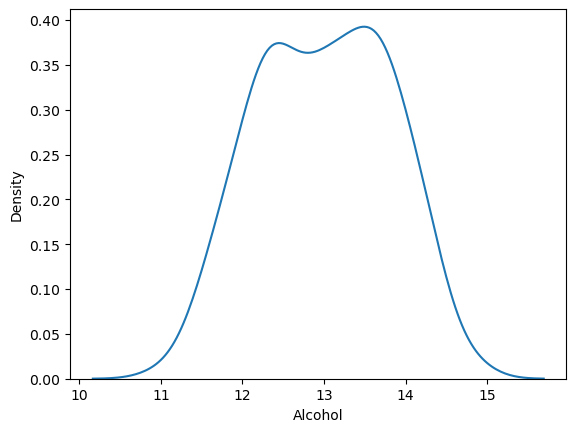

In [10]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Alcohol', ylabel='Malic_Acid'>

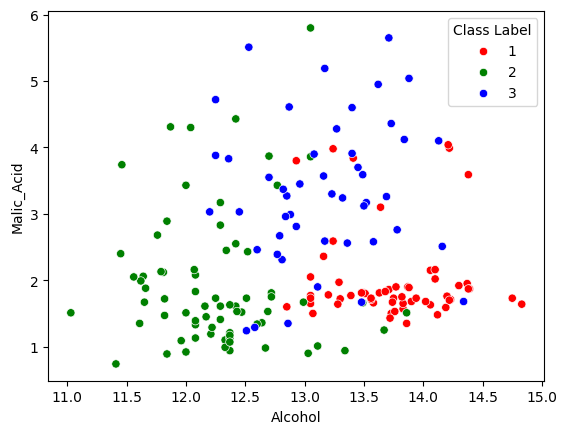

In [12]:
color_dict = {1:'red', 2:'green', 3:'blue'}
sns.scatterplot(x='Alcohol', y='Malic_Acid', hue='Class Label', data=df, palette=color_dict)

In [15]:
## train test split
X = df[['Alcohol', 'Malic_Acid']]
y = df['Class Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)

MinMaxScaler()

In [18]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
X_test_scaled = pd.DataFrame(X_test_scaled, columns=['Alcohol', 'Malic_Acid'])

In [20]:
X_test_scaled   =   pd.DataFrame(X_test_scaled, columns=['Alcohol', 'Malic_Acid'])

In [26]:
np.round(X_test.describe(), 1)

,Alcohol,Malic_Acid
count,54.0,54.0
mean,13.1,2.2
std,0.7,1.1
min,11.4,0.7
25%,12.4,1.4
50%,13.2,1.7
75%,13.6,2.8
max,14.3,5.5


In [27]:
np.round(X_test_scaled.describe(), 1)

,Alcohol,Malic_Acid
count,54.0,54.0
mean,0.5,0.3
std,0.2,0.2
min,0.1,-0.0
25%,0.4,0.1
50%,0.6,0.2
75%,0.7,0.4
max,0.9,0.9


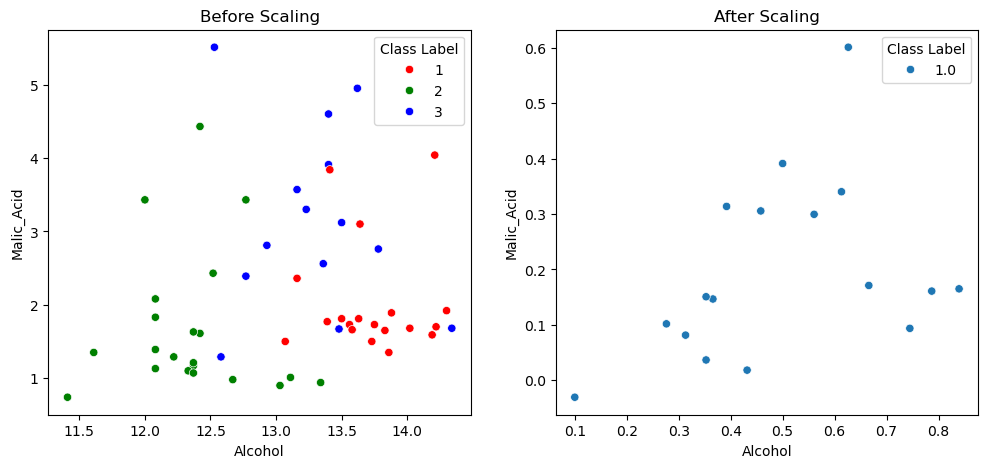

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.set_title('Before Scaling')
sns.scatterplot(x='Alcohol', y='Malic_Acid', hue='Class Label', data=X_test.join(y_test), palette=color_dict, ax=ax1)
ax2.set_title('After Scaling')
sns.scatterplot(x='Alcohol', y='Malic_Acid', hue='Class Label', data=X_test_scaled.join(y_test) , ax=ax2)    
plt.show()